In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

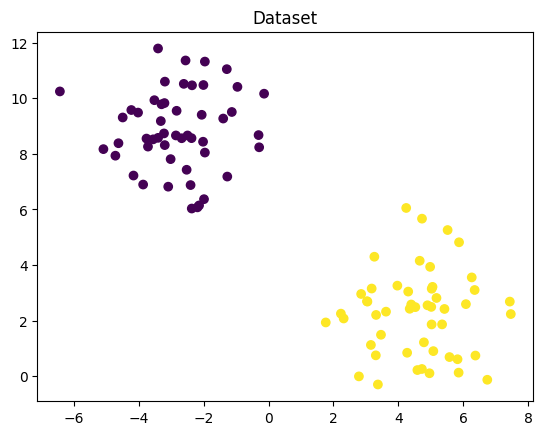

In [2]:
# Load dataset
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

# Plot data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset")
plt.show()

In [3]:
model_linear = SVC(kernel='linear')
model_linear.fit(X, y)

SVC(kernel='linear')

In [5]:
def plot_decision_boundary(model, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    # plot boundary
    ax.contour(XX, YY, Z, levels=[0])

    plt.title(title)
    plt.show()

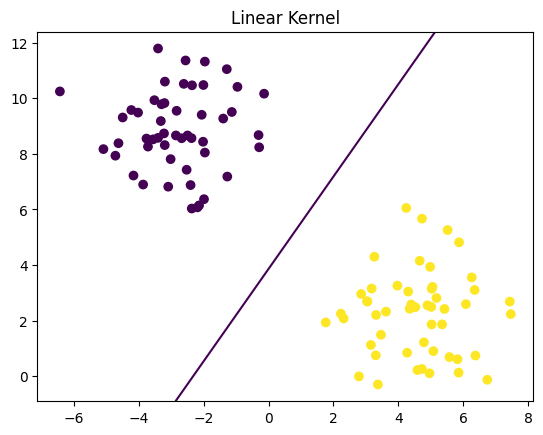

In [6]:
plot_decision_boundary(model_linear, X, y, "Linear Kernel")

In [7]:
model_rbf = SVC(kernel='rbf', gamma=1)
model_rbf.fit(X, y)

SVC(gamma=1)

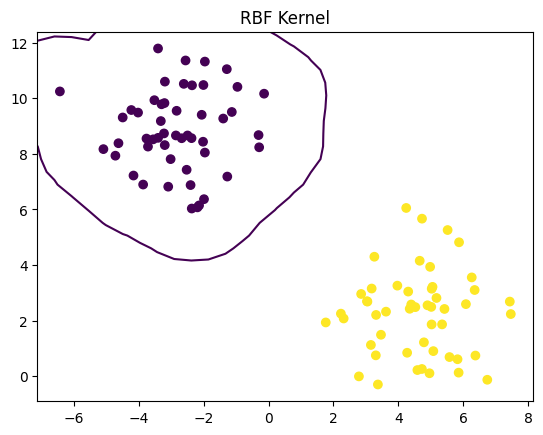

In [8]:
plot_decision_boundary(model_rbf, X, y, "RBF Kernel")

In [9]:
def plot_svm(model, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    # decision boundary + margins
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])

    # highlight support vectors
    ax.scatter(model.support_vectors_[:, 0],
               model.support_vectors_[:, 1],
               s=100, facecolors='none', edgecolors='k')

    plt.title(title)
    plt.show()

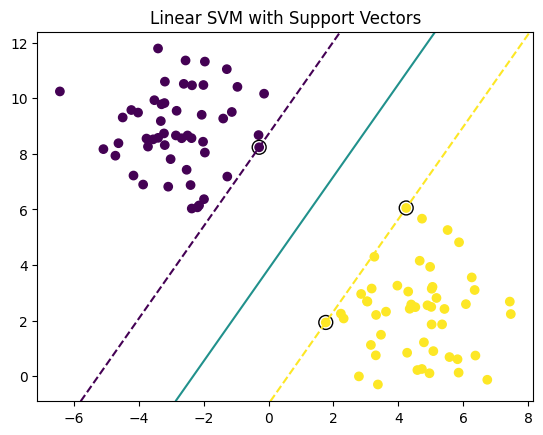

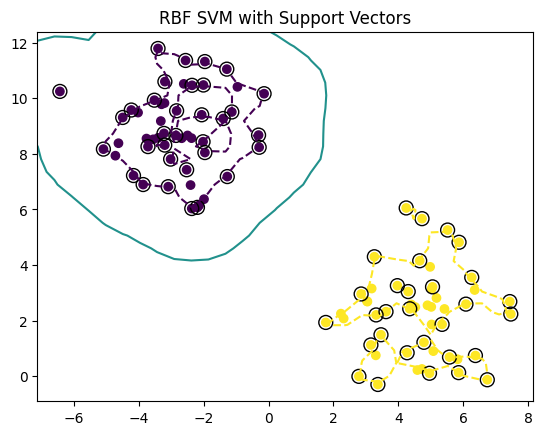

In [10]:
plot_svm(model_linear, X, y, "Linear SVM with Support Vectors")
plot_svm(model_rbf, X, y, "RBF SVM with Support Vectors")

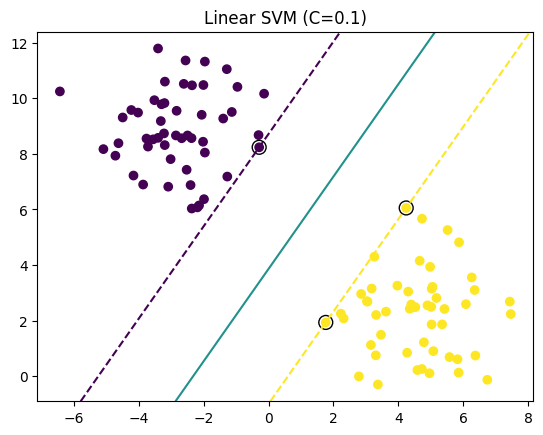

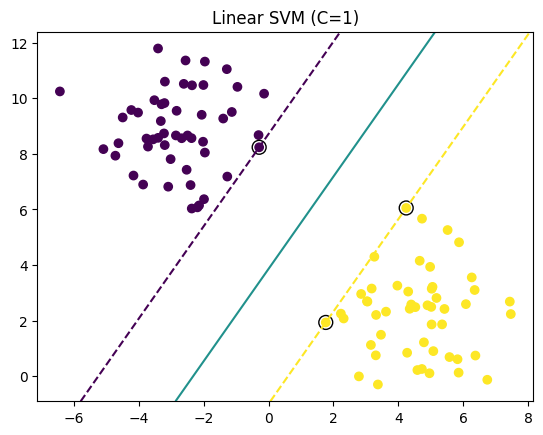

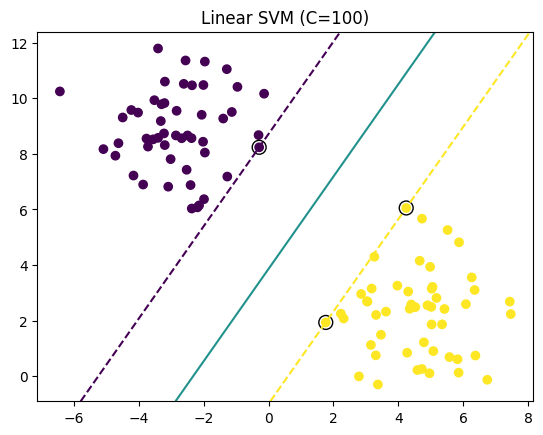

In [11]:
for C in [0.1, 1, 100]:
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)
    plot_svm(model, X, y, f"Linear SVM (C={C})")

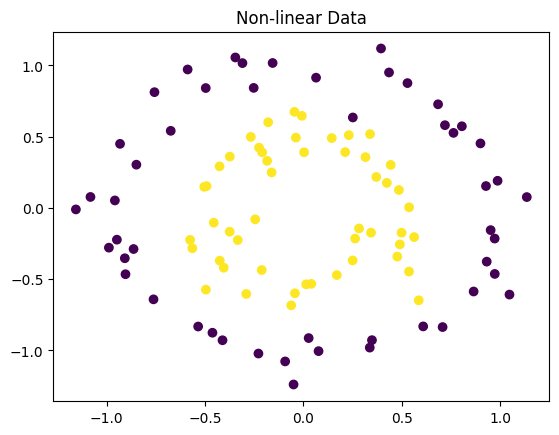

In [12]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=100, factor=0.5, noise=0.1)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Non-linear Data")
plt.show()

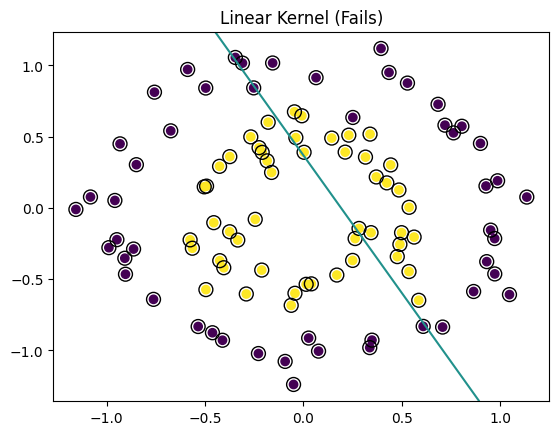

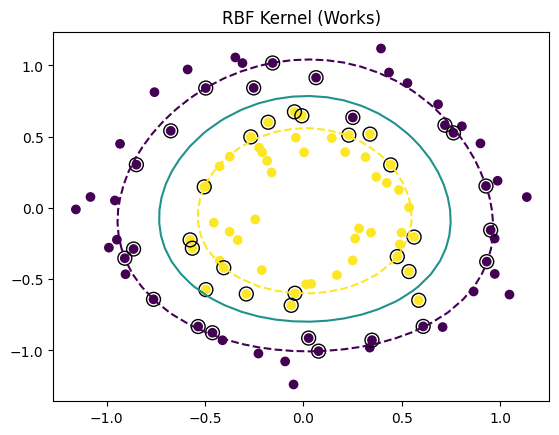

In [13]:
model_linear = SVC(kernel='linear')
model_linear.fit(X, y)

model_rbf = SVC(kernel='rbf', gamma=1)
model_rbf.fit(X, y)

plot_svm(model_linear, X, y, "Linear Kernel (Fails)")
plot_svm(model_rbf, X, y, "RBF Kernel (Works)")